In [1]:
import pandas as pd
import matplotlib.pyplot as plt

attendance_df = pd.read_excel(r"C:\Users\HP\gym_project\gym_data.xlsx", sheet_name="Attendance")

print(attendance_df.head())
print("Data loaded ✅")

  member_id visit_date  time_slot day_of_week
0      M001 2023-10-30    Evening      Monday
1      M001 2023-10-20  Afternoon      Friday
2      M001 2023-02-19  Afternoon      Sunday
3      M001 2023-02-08    Evening   Wednesday
4      M001 2023-06-25    Morning      Sunday
Data loaded ✅


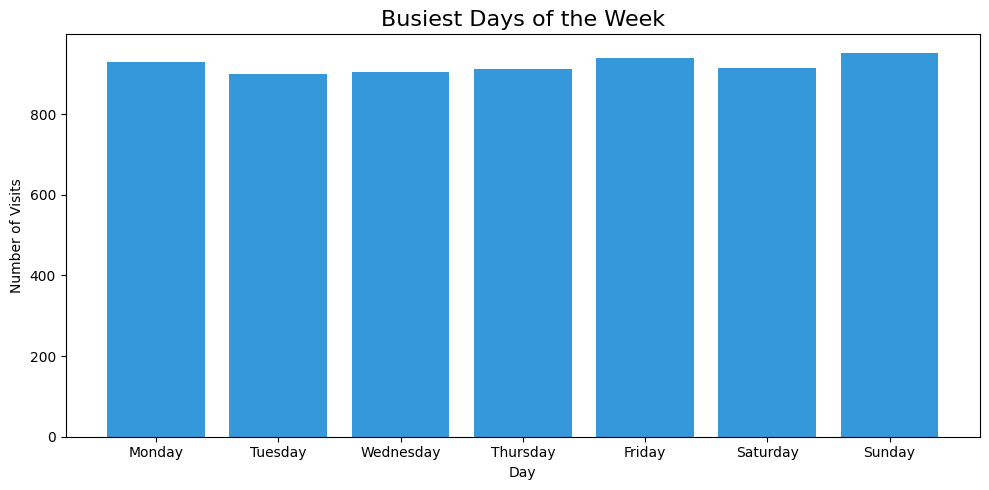

In [2]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_counts = attendance_df.groupby("day_of_week")["member_id"].count()
day_counts = day_counts.reindex(day_order)

plt.figure(figsize=(10, 5))
plt.bar(day_counts.index, day_counts.values, color="#3498db")
plt.title("Busiest Days of the Week", fontsize=16)
plt.xlabel("Day")
plt.ylabel("Number of Visits")
plt.tight_layout()
plt.show()

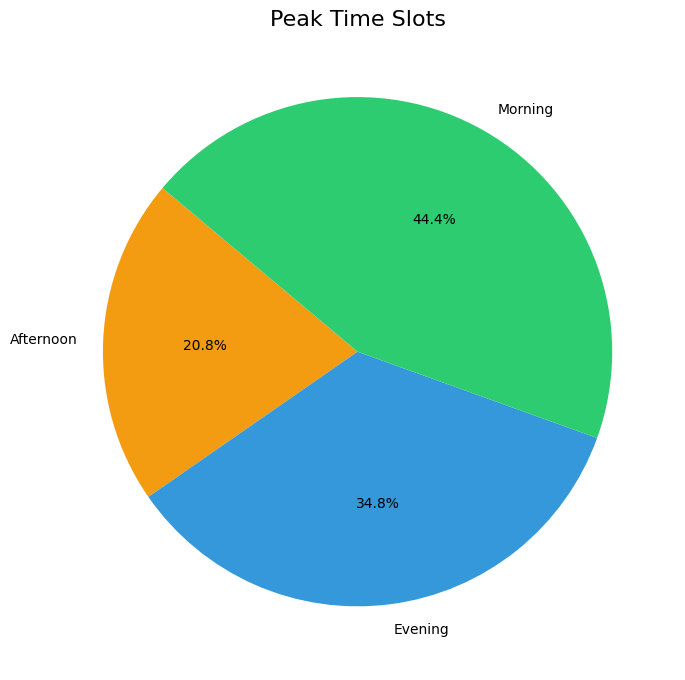

In [3]:
time_counts = attendance_df.groupby("time_slot")["member_id"].count()

plt.figure(figsize=(7, 7))
plt.pie(time_counts.values, labels=time_counts.index, autopct="%1.1f%%",
        colors=["#f39c12", "#3498db", "#2ecc71"], startangle=140)
plt.title("Peak Time Slots", fontsize=16)
plt.tight_layout()
plt.show()

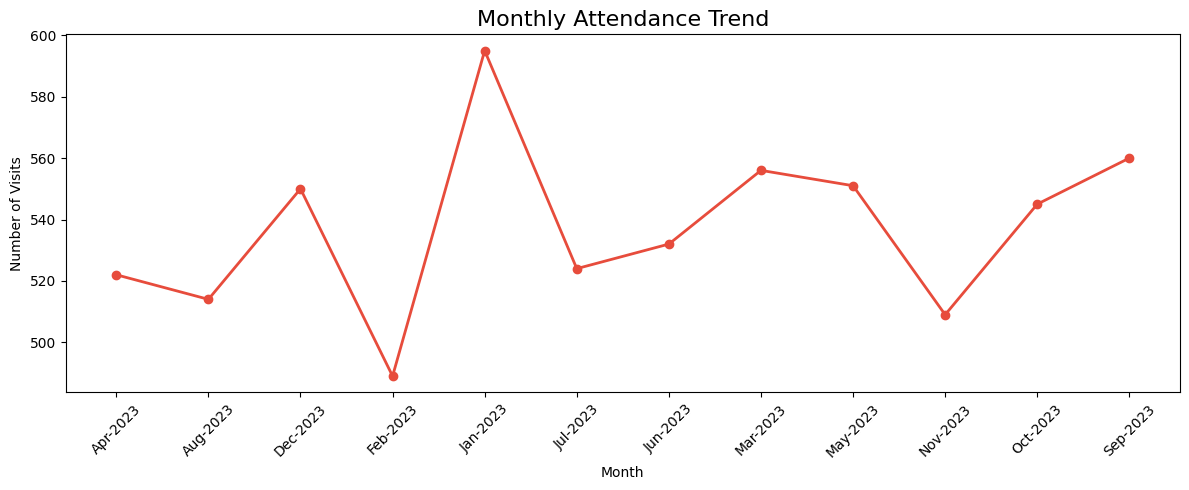

In [4]:
attendance_df["visit_date"] = pd.to_datetime(attendance_df["visit_date"])
attendance_df["visit_month"] = attendance_df["visit_date"].dt.strftime("%b-%Y")

monthly_visits = attendance_df.groupby("visit_month")["member_id"].count()

plt.figure(figsize=(12, 5))
plt.plot(monthly_visits.index, monthly_visits.values, marker="o", color="#e74c3c", linewidth=2)
plt.title("Monthly Attendance Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Number of Visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

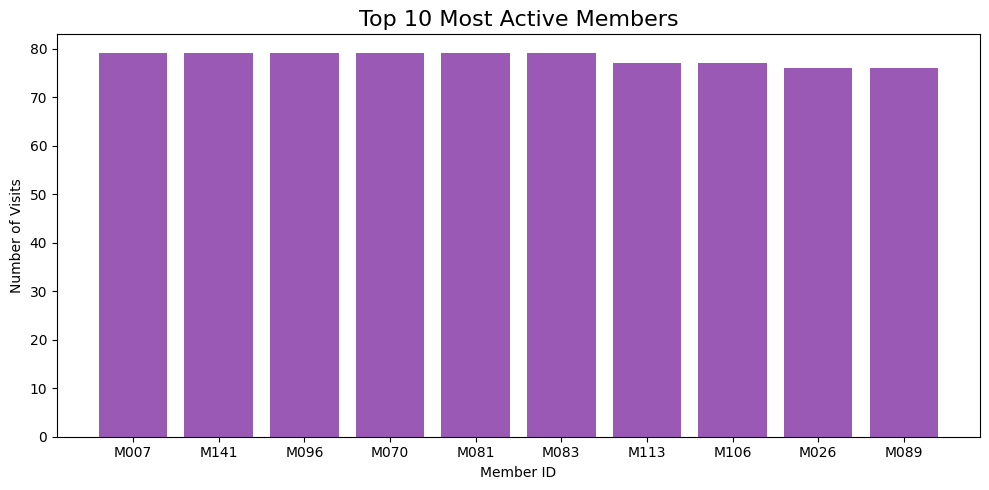

In [5]:
top_members = attendance_df.groupby("member_id")["visit_date"].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_members.index, top_members.values, color="#9b59b6")
plt.title("Top 10 Most Active Members", fontsize=16)
plt.xlabel("Member ID")
plt.ylabel("Number of Visits")
plt.tight_layout()
plt.show()